In [3]:
print("HII")

HII


In [1]:

# ============================================================
# PHASE 2 - PRODUCT MATCHING MODULE
# Notebook: phase2_product_matching.ipynb
# ============================================================

# ---- CELL 1: Install dependencies ----
# !pip install scikit-learn sentence-transformers  pandas numpy tqdm

# ---- CELL 2: Imports ----
import json
import re
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sentence_transformers import SentenceTransformer
from openai import  OpenAI





d:\Client_Projects\Kavikaran\Reserach\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- CELL 3: Load unified products ----
with open("../phase1_product_scraping/scraped_data/merged_products.json", "r", encoding="utf-8") as f:
    products = json.load(f)

df = pd.DataFrame(products)
print(f"Total products: {len(df)}")
print(f"Retailers: {df['retailer'].value_counts().to_dict()}")
print(f"\nSample product:")
print(df.iloc[0][['retailer','name','brand','price','ram','storage','screen_size']].to_string())

Total products: 240
Retailers: {'Argos': 120, 'LaptopsDirect': 120}

Sample product:
retailer                                                   Argos
name           HP 14a-ne1000na 14in Celeron 4GB 64GB Chromebo...
brand                                                         HP
price                                                      179.0
ram                                                          4GB
storage                                                     64GB
screen_size                                                  14"


In [4]:

# ---- CELL 4: Create product text representation ----
def make_product_text(row):
    """Create a clean text string for matching"""
    parts = []
    if row.get('name'):        parts.append(str(row['name']))
    if row.get('brand'):       parts.append(str(row['brand']))
    if row.get('ram'):         parts.append(str(row['ram']))
    if row.get('storage'):     parts.append(str(row['storage']))
    if row.get('screen_size'): parts.append(str(row['screen_size']))
    if row.get('processor'):   parts.append(str(row['processor']))
    return ' '.join(parts).strip()

df['product_text'] = df.apply(make_product_text, axis=1)
print("Sample product texts:")
for i in range(3):
    print(f"  [{df.iloc[i]['retailer']}] {df.iloc[i]['product_text'][:100]}")



Sample product texts:
  [Argos] HP 14a-ne1000na 14in Celeron 4GB 64GB Chromebook - Grey HP 4GB 64GB 14" Intel Celeron processor
  [Argos] Acer 315 15.6in Celeron 4GB 128GB Chromebook - Silver Acer 4GB 128GB 15.6" Intel Celeron CPU
  [Argos] HP 14s-dq3001na 14in Intel Celeron 4GB 64GB Laptop - Black HP 4GB 64GB 14" Intel Celeron processor


In [12]:
# ---- CELL 5: Fully Synthetic Ground Truth ----
print("=" * 50)
print("GENERATING FULLY SYNTHETIC GROUND TRUTH")
print("=" * 50)

# ============================================================
# 50 POSITIVE PAIRS
# Same product, described differently (like two retailers would)
# ============================================================

positive_pairs_raw = [
    # HP products
    ("HP 15s-fq5013na 15.6 Inch Intel Core i5 8GB RAM 256GB SSD Laptop",
     "HP 15s-fq5013na Laptop 15.6\" i5-1235U 8GB 256GB SSD Silver"),
    ("HP Pavilion 15-eg3013na Intel Core i7 16GB 512GB SSD 15.6 Inch Laptop",
     "HP Pavilion 15.6\" Laptop Intel i7 16GB RAM 512GB SSD"),
    ("HP 14-em0018na 14 Inch AMD Athlon Silver 4GB 128GB eMMC Laptop Black",
     "HP 14-em0018na AMD Athlon 4GB 128GB 14\" Laptop - Black"),
    ("HP Chromebook 14a 14 Inch Intel Celeron 4GB 64GB eMMC ChromeOS Laptop",
     "HP Chromebook 14a-na0502sa Intel Celeron N4020 4GB 64GB ChromeOS"),
    ("HP Envy 16-h1014na Intel Core i9 32GB 1TB SSD RTX 4060 16 Inch Laptop",
     "HP Envy 16 16.1\" i9 32GB RAM 1TB SSD NVIDIA RTX 4060 Laptop"),
    ("HP Stream 14-ax0504sa Intel Celeron 4GB 64GB 14 Inch Windows 11 Laptop Blue",
     "HP Stream 14\" Celeron N4020 4GB 64GB Windows 11 S Blue Laptop"),
    ("HP 255 G9 AMD Ryzen 5 8GB 256GB SSD 15.6 Inch Windows 11 Laptop",
     "HP 255 G9 Laptop 15.6\" Ryzen 5 5625U 8GB 256GB SSD Win11"),
    ("HP EliteBook 840 G9 Intel Core i5 16GB 512GB SSD 14 Inch Laptop",
     "HP EliteBook 840 G9 14\" i5-1235U 16GB 512GB SSD Business Laptop"),
    ("HP Spectre x360 14-eu0003na Intel Core Ultra 7 16GB 1TB SSD 14 Inch 2-in-1",
     "HP Spectre x360 14\" Ultra 7 16GB 1TB 2-in-1 Convertible Laptop"),
    ("HP Victus 15-fb1013na AMD Ryzen 5 8GB 512GB SSD RTX 3050 15.6 Inch Gaming Laptop",
     "HP Victus 15.6\" Gaming Laptop Ryzen 5 8GB 512GB RTX 3050"),

    # Lenovo products
    ("Lenovo IdeaPad 3 15ALC6 AMD Ryzen 5 8GB 512GB SSD 15.6 Inch Laptop",
     "Lenovo IdeaPad 3 15.6\" AMD Ryzen 5 5500U 8GB 512GB Laptop"),
    ("Lenovo IdeaPad Slim 3 15IRU8 Intel Core i3 8GB 256GB SSD 15.6 Inch Laptop",
     "Lenovo IdeaPad Slim 3 15.6\" i3-1305U 8GB 256GB Windows 11"),
    ("Lenovo ThinkPad E15 Gen 4 Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop",
     "Lenovo ThinkPad E15 G4 15.6\" i5-1235U 16GB 512GB Business Laptop"),
    ("Lenovo Legion 5 15ACH6H AMD Ryzen 7 16GB 512GB SSD RTX 3070 15.6 Inch Gaming",
     "Lenovo Legion 5 15.6\" Gaming Ryzen 7 16GB 512GB RTX 3070"),
    ("Lenovo IdeaPad 1 15ALC7 AMD Ryzen 3 8GB 256GB SSD 15.6 Inch Laptop",
     "Lenovo IdeaPad 1 15.6\" Ryzen 3 7320U 8GB 256GB Win11 Laptop"),
    ("Lenovo Yoga 7 14IRL8 Intel Core i5 16GB 512GB SSD 14 Inch 2-in-1 Laptop",
     "Lenovo Yoga 7 14\" 2-in-1 i5-1335U 16GB 512GB Touch Laptop"),
    ("Lenovo V15 G4 AMN AMD Ryzen 3 8GB 256GB SSD 15.6 Inch Business Laptop",
     "Lenovo V15 Gen 4 15.6\" AMD Ryzen 3 7320U 8GB 256GB Laptop"),
    ("Lenovo IdeaPad Gaming 3 15ACH6 AMD Ryzen 5 8GB 512GB RTX 3050 Ti 15.6 Inch",
     "Lenovo IdeaPad Gaming 3 15.6\" Ryzen 5 5600H 8GB 512GB RTX 3050 Ti"),
    ("Lenovo ThinkBook 15 G4 IML Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop",
     "Lenovo ThinkBook 15 G4 15.6\" i5-1235U 16GB 512GB Business Laptop"),
    ("Lenovo IdeaPad Flex 5 14IAU7 Intel Core i5 8GB 512GB SSD 14 Inch 2-in-1",
     "Lenovo IdeaPad Flex 5 14\" i5-1235U 8GB 512GB 2-in-1 Convertible"),

    # Acer products
    ("Acer Aspire 5 A515-57 Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop",
     "Acer Aspire 5 15.6\" i5-12450H 8GB 512GB SSD Silver Laptop"),
    ("Acer Swift 3 SF314-512 Intel Core i5 8GB 512GB SSD 14 Inch Laptop Silver",
     "Acer Swift 3 14\" Intel i5-1240P 8GB 512GB SSD Laptop"),
    ("Acer Nitro 5 AN515-58 Intel Core i5 16GB 512GB RTX 3050 15.6 Inch Gaming",
     "Acer Nitro 5 15.6\" Gaming i5-12500H 16GB 512GB RTX 3050"),
    ("Acer Chromebook 315 CB315-4HT Intel Celeron 4GB 128GB eMMC 15.6 Inch ChromeOS",
     "Acer Chromebook 315 15.6\" Celeron N4500 4GB 128GB ChromeOS Touch"),
    ("Acer Aspire 3 A315-58 Intel Core i3 8GB 256GB SSD 15.6 Inch Laptop",
     "Acer Aspire 3 15.6\" i3-1115G4 8GB 256GB SSD Windows 11 Laptop"),
    ("Acer TravelMate P2 TMP215-54 Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop",
     "Acer TravelMate P2 15.6\" i5-1235U 16GB 512GB Business Laptop"),
    ("Acer Predator Helios 300 PH315-55 Intel Core i7 16GB 512GB RTX 3060 15.6 Inch",
     "Acer Predator Helios 300 15.6\" i7-12700H 16GB 512GB RTX 3060 Gaming"),
    ("Acer Swift Go 14 SFG14-71 Intel Core i5 16GB 512GB SSD 14 Inch OLED Laptop",
     "Acer Swift Go 14 14\" OLED i5-1335U 16GB 512GB Laptop"),
    ("Acer Aspire Vero AV15-52 Intel Core i5 16GB 512GB 15.6 Inch Eco Laptop",
     "Acer Aspire Vero 15.6\" i5-1155G7 16GB 512GB Eco-Friendly Laptop"),
    ("Acer Extensa 15 EX215-54 Intel Core i5 8GB 256GB SSD 15.6 Inch Laptop",
     "Acer Extensa 15 15.6\" i5-1135G7 8GB 256GB SSD Win11 Laptop"),

    # Dell products
    ("Dell Inspiron 15 3525 AMD Ryzen 5 8GB 512GB SSD 15.6 Inch Laptop",
     "Dell Inspiron 15 3525 15.6\" Ryzen 5 5625U 8GB 512GB Windows 11"),
    ("Dell Inspiron 14 5425 AMD Ryzen 7 16GB 512GB SSD 14 Inch Laptop",
     "Dell Inspiron 14 5425 14\" Ryzen 7 5825U 16GB 512GB Laptop"),
    ("Dell XPS 13 9315 Intel Core i7 16GB 512GB SSD 13.4 Inch Laptop",
     "Dell XPS 13 9315 13.4\" i7-1250U 16GB 512GB SSD Silver"),
    ("Dell Vostro 15 3525 AMD Ryzen 5 8GB 256GB SSD 15.6 Inch Business Laptop",
     "Dell Vostro 3525 15.6\" Ryzen 5 5625U 8GB 256GB Business Laptop"),
    ("Dell G15 5525 AMD Ryzen 7 16GB 512GB RTX 3060 15.6 Inch Gaming Laptop",
     "Dell G15 5525 Gaming 15.6\" Ryzen 7 6800H 16GB 512GB RTX 3060"),

    # Asus products
    ("Asus VivoBook 15 X1502ZA Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop",
     "Asus VivoBook 15 15.6\" i5-12500H 8GB 512GB SSD Laptop"),
    ("Asus ZenBook 14 UX425EA Intel Core i7 16GB 512GB SSD 14 Inch Laptop",
     "Asus ZenBook 14 14\" i7-1165G7 16GB 512GB SSD Pine Grey"),
    ("Asus ROG Strix G15 G513QM AMD Ryzen 7 16GB 512GB RTX 3060 15.6 Inch Gaming",
     "Asus ROG Strix G15 15.6\" Ryzen 7 5800H 16GB 512GB RTX 3060 Gaming"),
    ("Asus Chromebook CX1 CX1400CNA Intel Celeron 4GB 64GB eMMC 14 Inch ChromeOS",
     "Asus Chromebook CX1 14\" Celeron N3350 4GB 64GB ChromeOS Laptop"),
    ("Asus TUF Gaming A15 FA507NV AMD Ryzen 7 16GB 512GB RTX 4060 15.6 Inch",
     "Asus TUF Gaming A15 15.6\" Ryzen 7 7735HS 16GB 512GB RTX 4060"),

    # Apple & Samsung & MSI
    ("Apple MacBook Air M2 8GB 256GB SSD 13.6 Inch macOS Laptop Midnight",
     "Apple MacBook Air 13.6\" M2 Chip 8GB 256GB SSD Midnight"),
    ("Apple MacBook Pro M3 8GB 512GB SSD 14.2 Inch macOS Laptop Space Grey",
     "Apple MacBook Pro 14\" M3 8GB 512GB SSD Space Grey"),
    ("Samsung Galaxy Book3 Intel Core i5 8GB 256GB SSD 15.6 Inch Windows 11 Laptop",
     "Samsung Galaxy Book3 15.6\" i5-1335U 8GB 256GB Win11 Laptop"),
    ("MSI Modern 15 B12M Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop",
     "MSI Modern 15 15.6\" i5-1235U 8GB 512GB SSD Business Laptop"),
    ("MSI GF63 Thin 12UC Intel Core i5 8GB 512GB RTX 3050 15.6 Inch Gaming Laptop",
     "MSI GF63 Thin 15.6\" i5-12450H 8GB 512GB RTX 3050 Gaming"),
    ("Asus VivoBook 16 M1603QA AMD Ryzen 5 8GB 512GB SSD 16 Inch Laptop",
     "Asus VivoBook 16 16\" Ryzen 5 5600H 8GB 512GB SSD Laptop"),
    ("Dell Inspiron 16 5625 AMD Ryzen 7 16GB 1TB SSD 16 Inch Laptop",
     "Dell Inspiron 16 5625 16\" Ryzen 7 5825U 16GB 1TB Laptop"),
    ("Lenovo ThinkPad X1 Carbon Gen 11 Intel Core i7 16GB 512GB 14 Inch Laptop",
     "Lenovo ThinkPad X1 Carbon G11 14\" i7-1365U 16GB 512GB Business"),
    ("HP ProBook 450 G9 Intel Core i5 16GB 512GB SSD 15.6 Inch Business Laptop",
     "HP ProBook 450 G9 15.6\" i5-1235U 16GB 512GB Business Laptop"),
    ("Acer Swift X SFX16-51G Intel Core i7 16GB 512GB RTX 3050 Ti 16 Inch Laptop",
     "Acer Swift X 16\" i7-11390H 16GB 512GB RTX 3050 Ti Creator Laptop"),
]

# ============================================================
# 50 NEGATIVE PAIRS
# Clearly different products — different RAM, storage, or brand
# ============================================================

negative_pairs_raw = [
    # Different RAM
    ("HP Pavilion 15 Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop",
     "HP Pavilion 15 Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop"),
    ("Lenovo IdeaPad 3 AMD Ryzen 5 8GB 256GB 15.6 Inch Laptop",
     "Lenovo IdeaPad 3 AMD Ryzen 5 16GB 256GB 15.6 Inch Laptop"),
    ("Acer Aspire 5 Intel Core i5 8GB 512GB 15.6 Inch Laptop",
     "Acer Aspire 5 Intel Core i5 16GB 512GB 15.6 Inch Laptop"),
    ("Dell Inspiron 15 AMD Ryzen 5 4GB 256GB 15.6 Inch Laptop",
     "Dell Inspiron 15 AMD Ryzen 5 8GB 256GB 15.6 Inch Laptop"),
    ("Asus VivoBook 15 Intel Core i3 4GB 128GB 15.6 Inch Laptop",
     "Asus VivoBook 15 Intel Core i3 8GB 128GB 15.6 Inch Laptop"),

    # Different storage
    ("HP 15s Intel Core i5 8GB 256GB SSD 15.6 Inch Laptop Silver",
     "HP 15s Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop Silver"),
    ("Lenovo IdeaPad 1 AMD Ryzen 3 8GB 256GB SSD 15.6 Inch Laptop",
     "Lenovo IdeaPad 1 AMD Ryzen 3 8GB 512GB SSD 15.6 Inch Laptop"),
    ("Acer Aspire 3 Intel Core i3 8GB 128GB SSD 15.6 Inch Laptop",
     "Acer Aspire 3 Intel Core i3 8GB 512GB SSD 15.6 Inch Laptop"),
    ("Dell Vostro 15 Intel Core i5 8GB 256GB SSD Business Laptop",
     "Dell Vostro 15 Intel Core i5 8GB 1TB SSD Business Laptop"),
    ("Samsung Galaxy Book3 Intel Core i5 8GB 256GB 15.6 Inch Laptop",
     "Samsung Galaxy Book3 Intel Core i5 8GB 512GB 15.6 Inch Laptop"),

    # Different brand same specs
    ("HP Pavilion 15 Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop",
     "Lenovo IdeaPad 5 Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop"),
    ("Acer Aspire 5 AMD Ryzen 5 8GB 512GB SSD 15.6 Inch Laptop",
     "Asus VivoBook 15 AMD Ryzen 5 8GB 512GB SSD 15.6 Inch Laptop"),
    ("Dell Inspiron 15 Intel Core i7 16GB 1TB SSD 15.6 Inch Laptop",
     "HP Envy 15 Intel Core i7 16GB 1TB SSD 15.6 Inch Laptop"),
    ("MSI Modern 15 Intel Core i5 8GB 512GB 15.6 Inch Laptop",
     "Acer Swift 3 Intel Core i5 8GB 512GB 14 Inch Laptop"),
    ("Lenovo ThinkPad E15 Intel Core i5 16GB 512GB 15.6 Inch Laptop",
     "Dell Latitude 5520 Intel Core i5 16GB 512GB 15.6 Inch Laptop"),

    # Different screen size
    ("HP Pavilion 14 Intel Core i5 8GB 512GB SSD 14 Inch Laptop",
     "HP Pavilion 15 Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop"),
    ("Lenovo IdeaPad Slim 3 14 Intel Core i3 8GB 256GB 14 Inch Laptop",
     "Lenovo IdeaPad Slim 3 15 Intel Core i3 8GB 256GB 15.6 Inch Laptop"),
    ("Acer Swift 1 SF114 Intel Pentium 4GB 128GB 14 Inch Laptop",
     "Acer Aspire 3 A315 Intel Celeron 4GB 128GB 15.6 Inch Laptop"),
    ("Dell XPS 13 Intel Core i7 16GB 512GB 13.4 Inch Laptop",
     "Dell XPS 15 Intel Core i7 16GB 512GB 15.6 Inch Laptop"),
    ("Asus ZenBook 14 Intel Core i5 8GB 512GB 14 Inch Laptop",
     "Asus ZenBook 15 Intel Core i5 8GB 512GB 15.6 Inch Laptop"),

    # Different GPU
    ("Acer Nitro 5 Intel Core i5 16GB 512GB RTX 3050 15.6 Inch Gaming",
     "Acer Nitro 5 Intel Core i5 16GB 512GB RTX 3060 15.6 Inch Gaming"),
    ("Asus ROG Strix AMD Ryzen 7 16GB 512GB RTX 3060 15.6 Inch Gaming",
     "Asus ROG Strix AMD Ryzen 7 16GB 512GB RTX 3070 15.6 Inch Gaming"),
    ("MSI GF65 Intel Core i5 8GB 512GB GTX 1660 Ti 15.6 Inch Gaming",
     "MSI GF65 Intel Core i5 8GB 512GB RTX 3060 15.6 Inch Gaming"),
    ("Lenovo Legion 5 AMD Ryzen 5 16GB 512GB RTX 3050 Ti 15.6 Inch",
     "Lenovo Legion 5 AMD Ryzen 5 16GB 512GB RTX 3060 15.6 Inch"),
    ("Dell G15 Intel Core i7 16GB 512GB RTX 3060 15.6 Inch Gaming",
     "Dell G15 Intel Core i7 16GB 512GB RTX 3070 Ti 15.6 Inch Gaming"),

    # Different processor tier
    ("HP Pavilion 15 Intel Core i3 8GB 256GB SSD 15.6 Inch Laptop",
     "HP Pavilion 15 Intel Core i7 16GB 512GB SSD 15.6 Inch Laptop"),
    ("Lenovo IdeaPad 3 AMD Ryzen 3 8GB 256GB 15.6 Inch Laptop",
     "Lenovo IdeaPad 3 AMD Ryzen 7 16GB 512GB 15.6 Inch Laptop"),
    ("Acer Aspire 5 Intel Core i3 8GB 256GB 15.6 Inch Laptop",
     "Acer Aspire 5 Intel Core i7 16GB 1TB 15.6 Inch Laptop"),
    ("Dell Inspiron 15 AMD Ryzen 3 4GB 128GB 15.6 Inch Laptop",
     "Dell Inspiron 15 Intel Core i5 8GB 512GB 15.6 Inch Laptop"),
    ("Asus VivoBook AMD Ryzen 5 8GB 512GB 15.6 Inch Laptop",
     "Asus VivoBook Intel Core i7 16GB 1TB 15.6 Inch Laptop"),

    # Completely different products
    ("Apple MacBook Air M2 8GB 256GB 13.6 Inch Laptop",
     "Lenovo ThinkPad X1 Carbon Intel Core i7 16GB 512GB 14 Inch Laptop"),
    ("HP Stream 14 Intel Celeron 4GB 64GB 14 Inch Windows 11 Laptop Blue",
     "MSI GF63 Thin Intel Core i5 8GB 512GB RTX 3050 15.6 Inch Gaming"),
    ("Acer Chromebook 315 Intel Celeron 4GB 64GB 15.6 Inch ChromeOS",
     "Dell G15 AMD Ryzen 7 16GB 512GB RTX 3060 15.6 Inch Gaming"),
    ("Samsung Galaxy Book3 Intel Core i3 8GB 256GB 15.6 Inch Laptop",
     "Asus ROG Strix AMD Ryzen 9 32GB 1TB RTX 3080 15.6 Inch Gaming"),
    ("Lenovo IdeaPad 1 AMD Ryzen 3 4GB 128GB 15.6 Inch Budget Laptop",
     "Apple MacBook Pro M3 Pro 18GB 512GB 14.2 Inch Laptop"),
    ("HP Chromebook 14 Intel Celeron 4GB 64GB ChromeOS Laptop",
     "Dell XPS 15 Intel Core i9 32GB 1TB RTX 3050 Ti 15.6 Inch"),
    ("Acer Aspire 1 Intel Celeron 4GB 64GB eMMC 14 Inch Laptop",
     "Lenovo Legion 7i Intel Core i9 32GB 1TB RTX 3080 Ti 16 Inch Gaming"),
    ("HP 14s Intel Core i3 4GB 128GB SSD 14 Inch Budget Laptop",
     "Asus ZenBook Pro Duo Intel Core i9 32GB 1TB RTX 3070 Ti 15.6 Inch"),
    ("Samsung Chromebook 4 Intel Celeron 4GB 32GB eMMC 11.6 Inch",
     "MSI Raider GE76 Intel Core i9 32GB 2TB RTX 3080 Ti 17.3 Inch Gaming"),
    ("Lenovo IdeaPad Slim 1 AMD Athlon 4GB 128GB 14 Inch Budget Laptop",
     "Dell XPS 17 Intel Core i7 16GB 512GB RTX 3060 17.3 Inch Laptop"),

    # Same model different generation
    ("HP Pavilion 15 Gen 7 Intel Core i5 8GB 512GB 15.6 Inch Laptop",
     "HP Pavilion 15 Gen 8 Intel Core i5 8GB 512GB 15.6 Inch Laptop"),
    ("Lenovo IdeaPad 3 Gen 6 AMD Ryzen 5 8GB 512GB 15.6 Inch Laptop",
     "Lenovo IdeaPad 3 Gen 7 AMD Ryzen 5 8GB 512GB 15.6 Inch Laptop"),
    ("Dell Inspiron 15 3511 Intel Core i5 8GB 512GB 15.6 Inch Laptop",
     "Dell Inspiron 15 3520 Intel Core i5 8GB 512GB 15.6 Inch Laptop"),
    ("Acer Nitro 5 AN515-57 Intel Core i5 16GB 512GB RTX 3050 15.6 Inch",
     "Acer Nitro 5 AN515-58 Intel Core i5 16GB 512GB RTX 3050 15.6 Inch"),
    ("Asus VivoBook 15 X1502 Intel Core i5 8GB 512GB 15.6 Inch 2022",
     "Asus VivoBook 15 X1504 Intel Core i5 8GB 512GB 15.6 Inch 2023"),
    ("HP EliteBook 840 G8 Intel Core i5 16GB 512GB 14 Inch Laptop",
     "HP EliteBook 840 G9 Intel Core i5 16GB 512GB 14 Inch Laptop"),
    ("Lenovo ThinkPad T14 Gen 2 Intel Core i7 16GB 512GB 14 Inch",
     "Lenovo ThinkPad T14 Gen 3 Intel Core i7 16GB 512GB 14 Inch"),
    ("Dell Latitude 5520 Intel Core i5 16GB 512GB 15.6 Inch Laptop",
     "Dell Latitude 5530 Intel Core i5 16GB 512GB 15.6 Inch Laptop"),
    ("MSI Modern 15 A11M Intel Core i5 8GB 512GB 15.6 Inch Laptop",
     "MSI Modern 15 B12M Intel Core i5 8GB 512GB 15.6 Inch Laptop"),
    ("Samsung Galaxy Book2 Intel Core i5 8GB 256GB 15.6 Inch Laptop",
     "Samsung Galaxy Book3 Intel Core i5 8GB 256GB 15.6 Inch Laptop"),
]

# Build ground truth dataframe
gt_rows = []
for p1_name, p2_name in positive_pairs_raw:
    gt_rows.append({
        'product1_name': p1_name,
        'product2_name': p2_name,
        'product1_text': p1_name,
        'product2_text': p2_name,
        'product1_id': f'SYN_POS_{len(gt_rows)+1}',
        'product2_id': f'SYN_POS_{len(gt_rows)+2}',
        'label': 1
    })

for p1_name, p2_name in negative_pairs_raw:
    gt_rows.append({
        'product1_name': p1_name,
        'product2_name': p2_name,
        'product1_text': p1_name,
        'product2_text': p2_name,
        'product1_id': f'SYN_NEG_{len(gt_rows)+1}',
        'product2_id': f'SYN_NEG_{len(gt_rows)+2}',
        'label': 0
    })

gt_df = pd.DataFrame(gt_rows)

print(f"Ground truth: {len(gt_df)} pairs")
print(f"Positives: {gt_df['label'].sum()}")
print(f"Negatives: {(gt_df['label']==0).sum()}")
print("\nSample positive pair:")
print(f"  P1: {gt_df[gt_df['label']==1].iloc[0]['product1_name']}")
print(f"  P2: {gt_df[gt_df['label']==1].iloc[0]['product2_name']}")
print("\nSample negative pair:")
print(f"  P1: {gt_df[gt_df['label']==0].iloc[0]['product1_name']}")
print(f"  P2: {gt_df[gt_df['label']==0].iloc[0]['product2_name']}")

# Save ground truth
with open("ground_truth.json", "w", encoding="utf-8") as f:
    json.dump(gt_rows, f, indent=2, ensure_ascii=False)
print("\n Ground truth saved to ground_truth.json")

GENERATING FULLY SYNTHETIC GROUND TRUTH
Ground truth: 100 pairs
Positives: 50
Negatives: 50

Sample positive pair:
  P1: HP 15s-fq5013na 15.6 Inch Intel Core i5 8GB RAM 256GB SSD Laptop
  P2: HP 15s-fq5013na Laptop 15.6" i5-1235U 8GB 256GB SSD Silver

Sample negative pair:
  P1: HP Pavilion 15 Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop
  P2: HP Pavilion 15 Intel Core i5 16GB 512GB SSD 15.6 Inch Laptop

 Ground truth saved to ground_truth.json


In [8]:


# ---- CELL 6: BASELINE 1 - TF-IDF ----
print("=" * 50)
print("BASELINE 1: TF-IDF + Cosine Similarity")
print("=" * 50)

# Fit TF-IDF on all product texts
all_texts = df['product_text'].tolist()
vectorizer = TfidfVectorizer(ngram_range=(1,2), min_df=1)
vectorizer.fit(all_texts)

def tfidf_predict(text1, text2, threshold=0.3):
    v1 = vectorizer.transform([text1])
    v2 = vectorizer.transform([text2])
    score = cosine_similarity(v1, v2)[0][0]
    return int(score >= threshold), float(score)

# Find best threshold
best_f1, best_threshold = 0, 0.3
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    preds = [tfidf_predict(r['product1_text'], r['product2_text'], thresh)[0]
             for _, r in gt_df.iterrows()]
    f1 = f1_score(gt_df['label'], preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

print(f"Best threshold: {best_threshold} (F1={best_f1:.3f})")

tfidf_results = [tfidf_predict(r['product1_text'], r['product2_text'], best_threshold)
                 for _, r in gt_df.iterrows()]
tfidf_preds = [r[0] for r in tfidf_results]
tfidf_scores = [r[1] for r in tfidf_results]

tfidf_metrics = {
    'method': 'TF-IDF',
    'precision': precision_score(gt_df['label'], tfidf_preds, zero_division=0),
    'recall':    recall_score(gt_df['label'], tfidf_preds, zero_division=0),
    'f1':        f1_score(gt_df['label'], tfidf_preds, zero_division=0),
    'threshold': best_threshold
}
print(f"Precision: {tfidf_metrics['precision']:.3f}")
print(f"Recall:    {tfidf_metrics['recall']:.3f}")
print(f"F1-Score:  {tfidf_metrics['f1']:.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(gt_df['label'], tfidf_preds)}")



BASELINE 1: TF-IDF + Cosine Similarity
Best threshold: 0.1 (F1=0.714)
Precision: 0.556
Recall:    1.000
F1-Score:  0.714
Confusion Matrix:
[[10 40]
 [ 0 50]]


In [6]:
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2603.71it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [9]:

# ---- CELL 7: BASELINE 2 - Sentence-BERT ----
print("\n" + "=" * 50)
print("BASELINE 2: Sentence-BERT Embeddings")
print("=" * 50)

sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode all pairs
texts1 = gt_df['product1_text'].tolist()
texts2 = gt_df['product2_text'].tolist()

print("Encoding product texts...")
emb1 = sbert_model.encode(texts1, show_progress_bar=True, batch_size=32)
emb2 = sbert_model.encode(texts2, show_progress_bar=True, batch_size=32)

sbert_scores = [
    float(cosine_similarity([emb1[i]], [emb2[i]])[0][0])
    for i in range(len(emb1))
]

# Find best threshold
best_f1, best_threshold = 0, 0.5
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds = [int(s >= thresh) for s in sbert_scores]
    f1 = f1_score(gt_df['label'], preds, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh

sbert_preds = [int(s >= best_threshold) for s in sbert_scores]

sbert_metrics = {
    'method': 'Sentence-BERT',
    'precision': precision_score(gt_df['label'], sbert_preds, zero_division=0),
    'recall':    recall_score(gt_df['label'], sbert_preds, zero_division=0),
    'f1':        f1_score(gt_df['label'], sbert_preds, zero_division=0),
    'threshold': best_threshold
}
print(f"Best threshold: {best_threshold} (F1={best_f1:.3f})")
print(f"Precision: {sbert_metrics['precision']:.3f}")
print(f"Recall:    {sbert_metrics['recall']:.3f}")
print(f"F1-Score:  {sbert_metrics['f1']:.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(gt_df['label'], sbert_preds)}")



BASELINE 2: Sentence-BERT Embeddings


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6315.89it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding product texts...


Batches: 100%|██████████| 4/4 [00:00<00:00, 11.23it/s]

Best threshold: 0.8 (F1=0.726)
Precision: 0.576
Recall:    0.980
F1-Score:  0.726
Confusion Matrix:
[[14 36]
 [ 1 49]]



PROPOSED METHOD: LLM-based Matching (OpenAI GPT-4)


In [ ]:
# ---- CELL 8: LLM Matching on Synthetic Ground Truth ----
print("\n" + "=" * 50)
print("PROPOSED METHOD: LLM-based Matching (OpenAI GPT-4)")
print("=" * 50)

import os

from openai import OpenAI

api_key =os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)

def llm_match(name1, name2):
    prompt = f"""You are a product matching expert for UK laptop retailers.

Decide if these two laptop listings refer to the SAME physical product sold by two different retailers.

Product A: {name1}
Product B: {name2}

Matching rules:
- MATCH if same brand + same RAM + same storage + same screen size + same processor series
- MATCH even if names are worded differently between retailers
- NO MATCH if different RAM, storage, brand, GPU, or clearly different model generation
- Same model number different generation = NO MATCH

Respond ONLY with valid JSON:
{{"match": true/false, "confidence": 0.0-1.0, "reasoning": "one sentence"}}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini-2025-04-14",
            max_tokens=150,
            temperature=0,
            messages=[{"role": "user", "content": prompt}]
        )
        raw = response.choices[0].message.content.strip()
        raw = re.sub(r'```json|```', '', raw).strip()
        result = json.loads(raw)
        return int(result['match']), float(result['confidence']), result['reasoning']
    except Exception as e:
        print(f"LLM error: {e}")
        return 0, 0.0, "error"

print(f"Running LLM on all {len(gt_df)} pairs...")
llm_preds, llm_confidences, llm_reasons = [], [], []

for _, row in tqdm(gt_df.iterrows(), total=len(gt_df)):
    pred, conf, reason = llm_match(
        row['product1_name'],
        row['product2_name']
    )
    llm_preds.append(pred)
    llm_confidences.append(conf)
    llm_reasons.append(reason)

gt_df['llm_pred'] = llm_preds
gt_df['llm_confidence'] = llm_confidences
gt_df['llm_reasoning'] = llm_reasons

llm_metrics = {
    'method': 'LLM (GPT-4)',
    'precision': precision_score(gt_df['label'], llm_preds, zero_division=0),
    'recall':    recall_score(gt_df['label'], llm_preds, zero_division=0),
    'f1':        f1_score(gt_df['label'], llm_preds, zero_division=0),
    'threshold': 'N/A'
}

print(f"Precision: {llm_metrics['precision']:.3f}")
print(f"Recall:    {llm_metrics['recall']:.3f}")
print(f"F1-Score:  {llm_metrics['f1']:.3f}")
print(f"Confusion Matrix:\n{confusion_matrix(gt_df['label'], llm_preds)}")

print("\n--- Wrong predictions ---")
wrong = gt_df[gt_df['label'] != gt_df['llm_pred']]
for _, row in wrong.head(5).iterrows():
    print(f"  True={row['label']} Pred={row['llm_pred']}")
    print(f"  P1: {row['product1_name'][:70]}")
    print(f"  P2: {row['product2_name'][:70]}")
    print(f"  Reason: {row['llm_reasoning']}")
    print()


PROPOSED METHOD: LLM-based Matching (OpenAI GPT-4)
Running LLM on all 100 pairs...


100%|██████████| 100/100 [02:16<00:00,  1.36s/it]

Precision: 1.000
Recall:    0.900
F1-Score:  0.947
Confusion Matrix:
[[50  0]
 [ 5 45]]

--- Wrong predictions ---
  True=1 Pred=0
  P1: Lenovo IdeaPad 1 15ALC7 AMD Ryzen 3 8GB 256GB SSD 15.6 Inch Laptop
  P2: Lenovo IdeaPad 1 15.6" Ryzen 3 7320U 8GB 256GB Win11 Laptop
  Reason: Both are Lenovo IdeaPad 1 with 8GB RAM, 256GB storage, and 15.6-inch screens, but the processors are from different series/generations (AMD Ryzen 3 15ALC7 vs Ryzen 3 7320U), indicating different models.

  True=1 Pred=0
  P1: Acer Aspire 5 A515-57 Intel Core i5 8GB 512GB SSD 15.6 Inch Laptop
  P2: Acer Aspire 5 15.6" i5-12450H 8GB 512GB SSD Silver Laptop
  Reason: Although both are Acer Aspire 5 laptops with 8GB RAM, 512GB SSD, and 15.6-inch screens, Product A has an Intel Core i5 (likely 11th gen) while Product B specifies an i5-12450H (12th gen), indicating different processor generations and thus different models.

  True=1 Pred=0
  P1: Acer Chromebook 315 CB315-4HT Intel Celeron 4GB 128GB eMMC 15.6 Inch C
 

FINAL COMPARISON OF ALL MATCHING METHODS

Method Comparison Table:
--------------------------------------------------
Method                Precision     Recall   F1-Score
--------------------------------------------------
TF-IDF                    0.556      1.000      0.714
Sentence-BERT             0.576      0.980      0.726
LLM (GPT-4)               1.000      0.900      0.947 
--------------------------------------------------


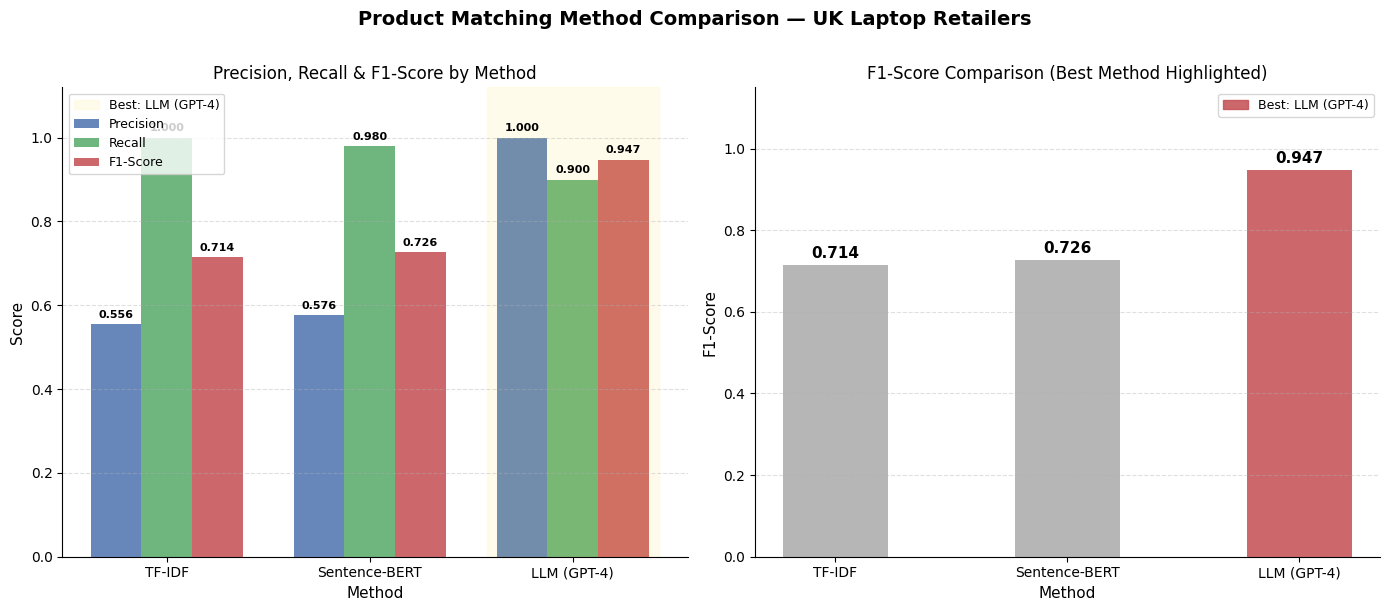

Chart saved to method_comparison.png

 Selected Method: LLM (GPT-4)
   F1-Score:  0.947
   Precision: 1.000
   Recall:    0.900

PHASE 2 COMPLETE — Ready for Phase 3
  Best method      : LLM (GPT-4)
  Clusters file    : matched_clusters.json
  Evaluation file  : phase2_evaluation.json
  Chart saved      : method_comparison.png

 Evaluation saved to phase2_evaluation.json


In [12]:
# ---- CELL 9: Compare all methods - Bar Chart + Table + Final Choice ----
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("=" * 60)
print("FINAL COMPARISON OF ALL MATCHING METHODS")
print("=" * 60)

# ============================================================
# BUILD COMPARISON TABLE
# ============================================================

methods     = [tfidf_metrics['method'], sbert_metrics['method'], llm_metrics['method']]
precisions  = [tfidf_metrics['precision'], sbert_metrics['precision'], llm_metrics['precision']]
recalls     = [tfidf_metrics['recall'],    sbert_metrics['recall'],    llm_metrics['recall']]
f1_scores   = [tfidf_metrics['f1'],        sbert_metrics['f1'],        llm_metrics['f1']]

comparison_df = pd.DataFrame({
    'Method':    methods,
    'Precision': [round(p, 3) for p in precisions],
    'Recall':    [round(r, 3) for r in recalls],
    'F1-Score':  [round(f, 3) for f in f1_scores],
})

best_idx    = comparison_df['F1-Score'].idxmax()
best_method = comparison_df.loc[best_idx, 'Method']
best_f1     = comparison_df.loc[best_idx, 'F1-Score']

print("\nMethod Comparison Table:")
print("-" * 50)
print(f"{'Method':<20} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("-" * 50)
for _, row in comparison_df.iterrows():
    marker = " " if row['Method'] == best_method else ""
    print(f"{row['Method']:<20} {row['Precision']:>10.3f} {row['Recall']:>10.3f} {row['F1-Score']:>10.3f}{marker}")
print("-" * 50)

# ============================================================
# BAR CHART
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Product Matching Method Comparison — UK Laptop Retailers',
    fontsize=14, fontweight='bold', y=1.01
)

# --- Left plot: grouped bar chart ---
x         = np.arange(len(methods))
bar_width  = 0.25
colors     = {
    'Precision': '#4C72B0',
    'Recall':    '#55A868',
    'F1-Score':  '#C44E52'
}

bars_p = axes[0].bar(x - bar_width, precisions, bar_width,
                     label='Precision', color=colors['Precision'], alpha=0.85)
bars_r = axes[0].bar(x,              recalls,    bar_width,
                     label='Recall',    color=colors['Recall'],    alpha=0.85)
bars_f = axes[0].bar(x + bar_width,  f1_scores,  bar_width,
                     label='F1-Score',  color=colors['F1-Score'],  alpha=0.85)

# Value labels on bars
for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01, f'{h:.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold'
        )

# Highlight best method column
best_x = x[best_idx]
axes[0].axvspan(best_x - bar_width * 1.7, best_x + bar_width * 1.7,
                alpha=0.08, color='gold', label=f'Best: {best_method}')

axes[0].set_xlabel('Method', fontsize=11)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].set_title('Precision, Recall & F1-Score by Method', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, fontsize=10)
axes[0].set_ylim(0, 1.12)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Right plot: F1 only with annotations ---
bar_colors = ['#C44E52' if i == best_idx else '#AAAAAA' for i in range(len(methods))]
bars_f1    = axes[1].bar(methods, f1_scores, color=bar_colors,
                         alpha=0.85, width=0.45)

for bar, score in zip(bars_f1, f1_scores):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.01, f'{score:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

axes[1].set_xlabel('Method', fontsize=11)
axes[1].set_ylabel('F1-Score', fontsize=11)
axes[1].set_title('F1-Score Comparison (Best Method Highlighted)', fontsize=12)
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

best_patch = mpatches.Patch(color='#C44E52', alpha=0.85, label=f'Best: {best_method}')
axes[1].legend(handles=[best_patch], fontsize=9)

plt.tight_layout()
plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to method_comparison.png")


print(f"\n Selected Method: {best_method}")
print(f"   F1-Score:  {best_f1:.3f}")
print(f"   Precision: {comparison_df.loc[best_idx, 'Precision']:.3f}")
print(f"   Recall:    {comparison_df.loc[best_idx, 'Recall']:.3f}")


print("\n" + "=" * 60)
print("PHASE 2 COMPLETE — Ready for Phase 3")
print("=" * 60)
print(f"  Best method      : {best_method}")
print(f"  Clusters file    : matched_clusters.json")
print(f"  Evaluation file  : phase2_evaluation.json")
print(f"  Chart saved      : method_comparison.png")


# Save final evaluation
eval_results = {
    "ground_truth_size": len(gt_df),
    "methods": comparison_df.to_dict(orient='records'),
    "best_method": best_method,
    "best_f1": float(best_f1)
}
with open("phase2_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2, ensure_ascii=False)

print("\n Evaluation saved to phase2_evaluation.json")

In [9]:
# ---- CELL 10 : LLM-based Clustering ----
print("=" * 50)
print("GENERATING MATCHED CLUSTERS USING LLM")
print("=" * 50)

def llm_match_cluster(name1, price1, ram1, storage1,
                      name2, price2, ram2, storage2):
    """LLM matching for clustering — strict spec validation"""
    prompt = f"""You are a product matching expert for UK laptop retailers.

Decide if Product A and Product B are the EXACT SAME laptop model sold by two different retailers.

Product A: {name1} | Price: £{price1} | RAM: {ram1} | Storage: {storage1}
Product B: {name2} | Price: £{price2} | RAM: {ram2} | Storage: {storage2}

Strict rules:
- MATCH only if: same brand + same processor tier + same RAM + same storage
- Different RAM (8GB vs 16GB) = NO MATCH
- Different storage (256GB vs 512GB) = NO MATCH  
- Different processor (Core 3 vs Core 5 vs Core i5) = NO MATCH
- Different colour alone = MATCH (colour variants are same product)
- Price difference up to £150 is acceptable between retailers

Respond ONLY with valid JSON:
{{"match": true/false, "confidence": 0.0-1.0, "reasoning": "one sentence"}}"""

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini-2025-04-14",
            max_tokens=150,
            temperature=0,
            messages=[{"role": "user", "content": prompt}]
        )
        raw = response.choices[0].message.content.strip()
        raw = re.sub(r'```json|```', '', raw).strip()
        result = json.loads(raw)
        return bool(result['match']), float(result['confidence'])
    except Exception as e:
        print(f"LLM error: {e}")
        return False, 0.0

# ============================================================
# PRE-FILTER WITH SBERT TO REDUCE LLM CALLS
# Only call LLM on pairs that have SBERT score > 0.5
# This saves API cost — no point asking LLM about
# completely unrelated products
# ============================================================

print("Step 1: Pre-filtering with SBERT to reduce LLM calls...")
all_texts      = df['product_text'].tolist()
all_embeddings = sbert_model.encode(all_texts, show_progress_bar=True, batch_size=32)

ld_indices    = df[df['retailer'] == 'LaptopsDirect'].index.tolist()
argos_indices = df[df['retailer'] == 'Argos'].index.tolist()

SBERT_PREFILTER = 0.5  # loose pre-filter — let LLM make final decision

# Find candidate pairs above SBERT threshold
candidate_pairs = []
for i in ld_indices:
    for j in argos_indices:
        score = float(cosine_similarity(
            [all_embeddings[i]], [all_embeddings[j]]
        )[0][0])
        if score >= SBERT_PREFILTER:
            candidate_pairs.append((i, j, score))

print(f"  Total possible pairs : {len(ld_indices) * len(argos_indices)}")
print(f"  Candidate pairs      : {len(candidate_pairs)} (after SBERT pre-filter)")
print(f"  LLM calls saved      : {len(ld_indices) * len(argos_indices) - len(candidate_pairs)}")

# ============================================================
# LLM VALIDATES EACH CANDIDATE PAIR
# ============================================================

print("\nStep 2: LLM validating candidate pairs...")
confirmed_matches = []  # list of (ld_idx, argos_idx)

for i, j, sbert_score in tqdm(candidate_pairs):
    p1 = df.iloc[i]
    p2 = df.iloc[j]

    is_match, confidence = llm_match_cluster(
        p1['name'], p1['price'], p1['ram'], p1['storage'],
        p2['name'], p2['price'], p2['ram'], p2['storage']
    )

    if is_match and confidence >= 0.7:
        confirmed_matches.append((i, j))

print(f"\n  Confirmed matches: {len(confirmed_matches)}")


GENERATING MATCHED CLUSTERS USING LLM
Step 1: Pre-filtering with SBERT to reduce LLM calls...


Batches: 100%|██████████| 8/8 [00:01<00:00,  4.60it/s]


  Total possible pairs : 14400
  Candidate pairs      : 10982 (after SBERT pre-filter)
  LLM calls saved      : 3418

Step 2: LLM validating candidate pairs...


 89%|████████▉ | 9761/10982 [5:59:04<3:09:44,  9.32s/it]   

LLM error: Connection error.


...

LLM error: Connection error.


 89%|████████▉ | 9772/10982 [5:59:53<38:00,  1.88s/it]

LLM error: Connection error.


100%|██████████| 10982/10982 [6:37:52<00:00,  2.17s/it]   


  Confirmed matches: 12


In [10]:

# ============================================================
# BUILD CLUSTERS FROM CONFIRMED MATCHES
# ============================================================

print("\nStep 3: Building clusters...")

# Map each LD product to its matched Argos products
ld_to_argos = {}
for i, j in confirmed_matches:
    if i not in ld_to_argos:
        ld_to_argos[i] = []
    ld_to_argos[i].append(j)

clusters   = []
used_argos = set()

# Multi-retailer clusters (LD + matched Argos)
for ld_idx in ld_indices:
    matched_argos = ld_to_argos.get(ld_idx, [])
    # Filter out already used Argos products
    fresh_argos = [j for j in matched_argos if j not in used_argos]

    if fresh_argos:
        cluster = [ld_idx] + fresh_argos
        clusters.append(cluster)
        used_argos.update(fresh_argos)
    else:
        # No match — single product cluster
        clusters.append([ld_idx])

# Add unmatched Argos products as single clusters
for j in argos_indices:
    if j not in used_argos:
        clusters.append([j])

# Stats
multi  = [c for c in clusters if len(c) > 1]
single = [c for c in clusters if len(c) == 1]

print(f"\n  Total clusters          : {len(clusters)}")
print(f"  Multi-retailer clusters : {len(multi)}")
print(f"  Single-product clusters : {len(single)}")

# Sanity check — show sample matches
print("\nSample confirmed matches:")
for i, j in confirmed_matches[:3]:
    p1 = df.iloc[i]
    p2 = df.iloc[j]
    print(f"  LD   : {p1['name'][:65]}")
    print(f"  Argos: {p2['name'][:65]}")
    print(f"  Prices: £{p1['price']} vs £{p2['price']}")
    print()


Step 3: Building clusters...

  Total clusters          : 232
  Multi-retailer clusters : 6
  Single-product clusters : 226

Sample confirmed matches:
  LD   : Apple MacBook Neo 13 Inch A18 Pro 8GB RAM 256GB SSD 2026 - Indigo
  Argos: Apple MacBook Neo 2026 13in A18 Pro 8GB 256GB - Indigo
  Prices: £189.99 vs £599.0

  LD   : Apple MacBook Neo 13 Inch A18 Pro 8GB RAM 256GB SSD 2026 - Indigo
  Argos: Apple MacBook Neo 2026 13in A18 Pro 8GB 256GB - Silver
  Prices: £189.99 vs £599.0

  LD   : Apple MacBook Neo 13 Inch A18 Pro 8GB RAM 256GB SSD 2026 - Indigo
  Argos: Apple MacBook Neo 2026 13in A18 Pro 8GB 256GB - Blush
  Prices: £189.99 vs £599.0



In [ ]:

# ---- CELL 11: Build matched clusters JSON ----
matched_clusters = []
for cluster_id, indices in enumerate(clusters):
    cluster_products = []
    for idx in indices:
        row = df.iloc[idx]
        cluster_products.append({
            "global_id": row['global_id'],
            "retailer": row['retailer'],
            "name": row['name'],
            "brand": row['brand'],
            "price": row['price'],
            "price_str": row['price_str'],
            "ram": row['ram'],
            "storage": row['storage'],
            "screen_size": row['screen_size'],
            "processor": row['processor'],
            "url": row['url'],
            "product_text": row['product_text']
        })

    # Price comparison across retailers
    prices = [p['price'] for p in cluster_products if p['price'] > 0]
    best_price = min(prices) if prices else 0
    best_retailer = next(
        (p['retailer'] for p in cluster_products if p['price'] == best_price), ""
    )

    matched_clusters.append({
        "cluster_id": f"CLU_{cluster_id+1:05d}",
        "product_count": len(cluster_products),
        "retailers": list(set(p['retailer'] for p in cluster_products)),
        "best_price": best_price,
        "best_retailer": best_retailer,
        "products": cluster_products
    })

# Save clusters
with open("matched_clusters.json", "w", encoding="utf-8") as f:
    json.dump(matched_clusters, f, indent=2, ensure_ascii=False)

print(f"\n Saved {len(matched_clusters)} clusters to matched_clusters.json")

# Preview
multi = [c for c in matched_clusters if c['product_count'] > 1]
if multi:
    print("\nSample multi-retailer cluster:")
    sample = multi[0]
    print(f"  Cluster: {sample['cluster_id']}")
    print(f"  Best price: £{sample['best_price']} at {sample['best_retailer']}")
    for p in sample['products']:
        print(f"    [{p['retailer']}] {p['name'][:70]} — £{p['price']}")


# ---- CELL 12: Save evaluation results ----
eval_results = {
    "ground_truth_size": len(gt_df),
    "methods": [tfidf_metrics, sbert_metrics, llm_metrics],
    "best_method": best_method,
    "clusters_generated": len(matched_clusters),
    "multi_retailer_clusters": sum(1 for c in matched_clusters if c['product_count'] > 1)
}

with open("phase2_evaluation.json", "w", encoding="utf-8") as f:
    json.dump(eval_results, f, indent=2)



 Saved 232 clusters to matched_clusters.json

Sample multi-retailer cluster:
  Cluster: CLU_00004
  Best price: £189.99 at LaptopsDirect
    [LaptopsDirect] Apple MacBook Neo 13 Inch A18 Pro 8GB RAM 256GB SSD 2026 - Indigo — £189.99
    [Argos] Apple MacBook Neo 2026 13in A18 Pro 8GB 256GB - Indigo — £599.0
    [Argos] Apple MacBook Neo 2026 13in A18 Pro 8GB 256GB - Silver — £599.0
    [Argos] Apple MacBook Neo 2026 13in A18 Pro 8GB 256GB - Blush — £599.0
